# 07. Offseason Head-to-Head Cross-Tier Analysis

This notebook evaluates team and player performance in **untiered / offseason matches** played between teams that have competed in tiered tournaments (VCT, VCL, GC, etc.).

We dynamically classify each team's tier at the time of the offseason match by locating their **latest tiered match** played strictly prior to that offseason match (using patch version and match ID to determine chronological order).

Furthermore, we control for roster stability by matching player names in the offseason match against their tier-determining matches.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_tables, enrich_matches, get_completed_maps, savefig

pd.set_option('display.max_columns', None)
tables = load_tables()
matches = enrich_matches(tables['matches'])
pstats = tables['map_player_stats']
maps = tables['maps']

In [2]:
def parse_patch(patch_str):
    if not patch_str or pd.isna(patch_str):
        return (0, 0)
    parts = re.findall(r'\d+', str(patch_str))
    if len(parts) >= 2:
        return (int(parts[0]), int(parts[1]))
    elif len(parts) == 1:
        return (int(parts[0]), 0)
    return (0, 0)

matches['patch_parsed'] = matches['patch'].apply(parse_patch)

In [3]:
# Extract all match appearances for each team with their event-based tier
team_history = pd.concat([
    matches[['match_id', 'patch_parsed', 'team1_id', 'tier']].rename(columns={'team1_id': 'team_id'}),
    matches[['match_id', 'patch_parsed', 'team2_id', 'tier']].rename(columns={'team2_id': 'team_id'})
]).dropna(subset=['tier'])

# Sort history chronologically: first by patch, then by match_id
team_history = team_history.sort_values(by=['patch_parsed', 'match_id']).reset_index(drop=True)

# Group by team_id for fast lookup
team_grouped = {team_id: grp.to_dict(orient='records') for team_id, grp in team_history.groupby('team_id')}

# Filter for untiered matches
untiered_matches = matches[
    (matches['status'] == 'final') &
    (matches['tier'].isna())
].copy()
print(f"Untiered final matches in database: {len(untiered_matches):,}")

Untiered final matches in database: 3,547


In [4]:
# Extract player names for each (match_id, team_id)
rosters = pstats.groupby(['match_id', 'team_id'])['player_name'].apply(set).to_dict()

In [5]:
# Resolve team tiers and calculate roster overlaps for each untiered match
resolved_records = []

for idx, row in untiered_matches.iterrows():
    m_id = row['match_id']
    patch_p = row['patch_parsed']
    t1_id = row['team1_id']
    t2_id = row['team2_id']
    winner_id = row['winner_team_id']
    event_name = row['event_name']
    
    t1_rost = rosters.get((m_id, t1_id), set())
    t2_rost = rosters.get((m_id, t2_id), set())
    
    if not t1_rost or not t2_rost:
        continue
        
    # Find latest tiered match for team 1 before this match
    t1_det_match, t1_tier = None, None
    if t1_id in team_grouped:
        for hist in reversed(team_grouped[t1_id]):
            if hist['patch_parsed'] < patch_p or (hist['patch_parsed'] == patch_p and int(hist['match_id']) < int(m_id)):
                t1_det_match = hist['match_id']
                t1_tier = hist['tier']
                break
                
    # Find latest tiered match for team 2 before this match
    t2_det_match, t2_tier = None, None
    if t2_id in team_grouped:
        for hist in reversed(team_grouped[t2_id]):
            if hist['patch_parsed'] < patch_p or (hist['patch_parsed'] == patch_p and int(hist['match_id']) < int(m_id)):
                t2_det_match = hist['match_id']
                t2_tier = hist['tier']
                break
                
    if t1_det_match and t2_det_match:
        t1_det_rost = rosters.get((t1_det_match, t1_id), set())
        t2_det_rost = rosters.get((t2_det_match, t2_id), set())
        
        if t1_det_rost and t2_det_rost:
            o1 = len(t1_rost & t1_det_rost)
            o2 = len(t2_rost & t2_det_rost)
            
            resolved_records.append({
                'match_id': m_id,
                'event_name': event_name,
                'team1_id': t1_id,
                'team2_id': t2_id,
                'team1_tier': t1_tier,
                'team2_tier': t2_tier,
                'winner_team_id': winner_id,
                't1_overlap': o1,
                't2_overlap': o2
            })

df_res = pd.DataFrame(resolved_records)
df_diff = df_res[df_res['team1_tier'] != df_res['team2_tier']].copy()
print(f"Resolved matches between DIFFERENT tiers: {len(df_diff):,}")

Resolved matches between DIFFERENT tiers: 593


## Head-to-Head Win Rates under Roster Stability Filters

In [6]:
def analyze_filtered(df, name_filter, o_min1, o_min2):
    sub_df = df[(df['t1_overlap'] >= o_min1) & (df['t2_overlap'] >= o_min2)].copy()
    print(f'\n--- Analysis for: {name_filter} (n={len(sub_df)}) ---')
    
    # Tier 1 vs Tier 2
    t1_vs_t2 = sub_df[
        ((sub_df['team1_tier'] == 'tier1') & (sub_df['team2_tier'] == 'tier2')) |
        ((sub_df['team1_tier'] == 'tier2') & (sub_df['team2_tier'] == 'tier1'))
    ].copy()
    if len(t1_vs_t2) > 0:
        t1_vs_t2['t1_won'] = t1_vs_t2.apply(lambda r: 1 if (r['team1_tier']=='tier1' and r['winner_team_id']==r['team1_id']) or (r['team2_tier']=='tier1' and r['winner_team_id']==r['team2_id']) else 0, axis=1)
        print(f'  Tier 1 vs Tier 2: win rate = {t1_vs_t2["t1_won"].mean():.2%} (n={len(t1_vs_t2)})')
        
    # Tier 1 vs Tier 3
    t1_vs_t3 = sub_df[
        ((sub_df['team1_tier'] == 'tier1') & (sub_df['team2_tier'] == 'tier3')) |
        ((sub_df['team1_tier'] == 'tier3') & (sub_df['team2_tier'] == 'tier1'))
    ].copy()
    if len(t1_vs_t3) > 0:
        t1_vs_t3['t1_won'] = t1_vs_t3.apply(lambda r: 1 if (r['team1_tier']=='tier1' and r['winner_team_id']==r['team1_id']) or (r['team2_tier']=='tier1' and r['winner_team_id']==r['team2_id']) else 0, axis=1)
        print(f'  Tier 1 vs Tier 3: win rate = {t1_vs_t3["t1_won"].mean():.2%} (n={len(t1_vs_t3)})')
        
    # Tier 2 vs Tier 3
    t2_vs_t3 = sub_df[
        ((sub_df['team1_tier'] == 'tier2') & (sub_df['team2_tier'] == 'tier3')) |
        ((sub_df['team1_tier'] == 'tier3') & (sub_df['team2_tier'] == 'tier2'))
    ].copy()
    if len(t2_vs_t3) > 0:
        t2_vs_t3['t2_won'] = t2_vs_t3.apply(lambda r: 1 if (r['team1_tier']=='tier2' and r['winner_team_id']==r['team1_id']) or (r['team2_tier']=='tier2' and r['winner_team_id']==r['team2_id']) else 0, axis=1)
        print(f'  Tier 2 vs Tier 3: win rate = {t2_vs_t3["t2_won"].mean():.2%} (n={len(t2_vs_t3)})')

analyze_filtered(df_diff, 'Unfiltered (Any Overlap)', 0, 0)
analyze_filtered(df_diff, 'Stable Core (>= 4/5 overlap for both teams)', 4, 4)
analyze_filtered(df_diff, 'Strictly Identical Rosters (5/5 overlap for both teams)', 5, 5)


--- Analysis for: Unfiltered (Any Overlap) (n=593) ---
  Tier 1 vs Tier 2: win rate = 64.88% (n=205)
  Tier 1 vs Tier 3: win rate = 54.67% (n=225)
  Tier 2 vs Tier 3: win rate = 54.68% (n=139)

--- Analysis for: Stable Core (>= 4/5 overlap for both teams) (n=100) ---
  Tier 1 vs Tier 2: win rate = 70.59% (n=34)
  Tier 1 vs Tier 3: win rate = 70.73% (n=41)
  Tier 2 vs Tier 3: win rate = 60.87% (n=23)

--- Analysis for: Strictly Identical Rosters (5/5 overlap for both teams) (n=16) ---
  Tier 1 vs Tier 2: win rate = 71.43% (n=7)
  Tier 1 vs Tier 3: win rate = 50.00% (n=6)
  Tier 2 vs Tier 3: win rate = 50.00% (n=2)


## Generate Head-to-Head Heatmap

Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/offseason_h2h_heatmap.png


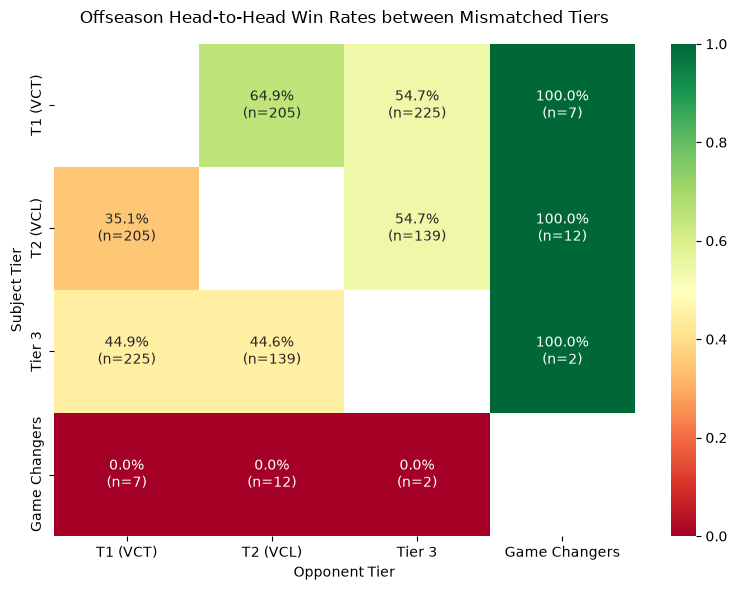

In [7]:
tiers = ['tier1', 'tier2', 'tier3', 'game_changers']
matrix = pd.DataFrame(np.nan, index=tiers, columns=tiers)
counts = pd.DataFrame(0, index=tiers, columns=tiers)

for t_a in tiers:
    for t_b in tiers:
        if t_a == t_b:
            continue
        sub = df_diff[
            ((df_diff['team1_tier'] == t_a) & (df_diff['team2_tier'] == t_b)) |
            ((df_diff['team1_tier'] == t_b) & (df_diff['team2_tier'] == t_a))
        ].copy()
        if len(sub) > 0:
            def a_won(r):
                if r['team1_tier'] == t_a:
                    return 1 if r['winner_team_id'] == r['team1_id'] else 0
                else:
                    return 1 if r['winner_team_id'] == r['team2_id'] else 0
            sub['a_won'] = sub.apply(a_won, axis=1)
            matrix.loc[t_a, t_b] = sub['a_won'].mean()
            counts.loc[t_a, t_b] = len(sub)

fig, ax = plt.subplots(figsize=(8, 6))
annot_labels = np.empty_like(matrix, dtype=object)
for i in range(len(tiers)):
    for j in range(len(tiers)):
        val = matrix.iloc[i, j]
        cnt = counts.iloc[i, j]
        if pd.notna(val):
            annot_labels[i, j] = f'{val:.1%}\n(n={cnt})'
        else:
            annot_labels[i, j] = '-'

sns.heatmap(matrix, annot=annot_labels, fmt='', cmap='RdYlGn', vmin=0.0, vmax=1.0, cbar=True, ax=ax,
            xticklabels=['T1 (VCT)', 'T2 (VCL)', 'Tier 3', 'Game Changers'],
            yticklabels=['T1 (VCT)', 'T2 (VCL)', 'Tier 3', 'Game Changers'])
ax.set_title('Offseason Head-to-Head Win Rates between Mismatched Tiers', fontsize=12, pad=15)
ax.set_xlabel('Opponent Tier')
ax.set_ylabel('Subject Tier')
plt.tight_layout()
savefig(fig, 'offseason_h2h_heatmap')
plt.show()